### Document Types in Anglo American corpus

1. Sustainability Reports (2020-2024) - long form pdf
2. Q4 production tables (2020-2024) - .xlsx
3. Production Report 2020-2024


### Chunking Test for ESG Factbook

In [3]:
import os

if os.name == "nt":
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
    print("Windows local workaround active: KMP_DUPLICATE_LIB_OK=TRUE")

Windows local workaround active: KMP_DUPLICATE_LIB_OK=TRUE


In [4]:
import torch

OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\elimo\miniconda3\envs\rag\Lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

In [ ]:
import re
import umap

import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

from utils import (
    bootstrap_runtime_env,
    resolve_pdf_workflow_config,
    chunk_by_char_limit,
    chunk_by_element_type,
    chunk_sentences_sliding,
    embed_chunks_w2v,
    rank_by_model,
    save_chunks_as_markdown,
)

bootstrap_runtime_env()

from sentence_transformers import SentenceTransformer
from unstructured.partition.pdf import partition_pdf

import pickle


In [4]:
tqdm.pandas()
import nltk

In [4]:
workflow = resolve_pdf_workflow_config()
PDF_PATH = workflow["pdf_path"]
OUTPUT_DIR = workflow["output_dir"]
QUERY_TEXT = "What are Anglo American near-term 2030 targets for Scope 1 and 2 and Scope 3 GHG emissions?"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PDF: {PDF_PATH.name}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Query: {QUERY_TEXT}")

PDF: ANTAM AR2016.pdf
Output dir: data\interim
Query: What are Anglo American near-term 2030 targets for Scope 1 and 2 and Scope 3 GHG emissions?


### Stage 1: Extraction and two chunking strategies

In [ ]:
elements = partition_pdf(
    filename=str(PDF_PATH), 
    strategy="fast"
)

In [7]:
with open(OUTPUT_DIR / "elements_fast.pkl", "wb") as f:
    pickle.dump(elements, f)

with open(OUTPUT_DIR / "elements_fast.pkl", "rb") as f:
    elements=pickle.load(f)

In [8]:
raw_texts = [
    el.text.strip()
    for el in tqdm(elements)
    if getattr(el, "text", None) and el.text.strip()
]

print(f"Elements extracted: {len(elements)}")
print(f"Text elements kept: {len(raw_texts)}")

  0%|          | 0/8976 [00:00<?, ?it/s]

Elements extracted: 8976
Text elements kept: 8815


#### Heading-delimited sections

In [9]:
el_types = pd.Series([type(el).__name__ for el in elements if (getattr(el, "text", None) or "").strip()])
el_types.value_counts()

Text             2981
Title            2375
NarrativeText    2262
ListItem          592
Footer            393
Header            211
Address             1
Name: count, dtype: int64

In [13]:
chunks_fast = chunk_by_element_type(elements, char_limit=1000, source_label=PDF_PATH.name)
chunks_fast = pd.DataFrame(chunks_fast).assign(char_count=lambda df: df["text"].str.len())

chunks_fast.describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,1076.0,818.238848,222.591372,23.0,707.75,861.5,954.0,2505.0


In [14]:
chunk_id = 2  # Change to see other chunks

print(f"Chunk ID: {chunks_fast.loc[chunk_id, 'id']}")
print(f"Element types: {chunks_fast.loc[chunk_id, 'element_types']} | Page numbers: {chunks_fast.loc[chunk_id, 'pages']}")
print(f"Chunk text:\n" + "="*80 + "\n")
print(f"{chunks_fast.loc[chunk_id, 'text']}")

Chunk ID: elem_0002
Element types: ['Footer', 'Header', 'ListItem', 'NarrativeText', 'Text', 'Title'] | Page numbers: [2]
Chunk text:

RUNNING TITLE: DELIVERING CHANGE BUILDING RESILIENCE FOUNDATIONS FOR THE FUTURE

HEADER (H2): INTRODUCTION

Throughout the Strategic Report we use a range of financial and non-financial measures to assess our performance. A number of the financial measures, including underlying earnings, underlying EBIT, underlying EBITDA, underlying earnings per share, net debt, attributable return on capital employed (ROCE) and attributable free cash flow are not defined under IFRS, so they are termed ‘Alternative Performance Measures’ (APMs).
Cover images 1. In South Africa, control room operators Priscilla Tsheole (left) and Maggy Botsanara monitor the stability of operations at the North Concentrator at Mogalakwena, Anglo American’s flagship platinum mine.
2. Process plant superintendent Terry Pinske walks up the ramp alongside the conveyor carrying diamond-bearing

In [15]:
tables = chunks_fast[chunks_fast["element_types"] == 'table']
print(f"Number of table chunks: {len(tables)}")

Number of table chunks: 0


In [ ]:
## Chunking Strategy using Auto

elements = partition_pdf(
    filename=str(PDF_PATH), 
    strategy="auto"
)

In [17]:
with open(OUTPUT_DIR / "elements_auto.pkl", "wb") as f:
    pickle.dump(elements, f)

with open(OUTPUT_DIR / "elements_auto.pkl", "rb") as f:
    elements=pickle.load(f)

In [ ]:
chunks_auto = chunk_by_element_type(elements, char_limit=1000, source_label=PDF_PATH.name)
chunks_auto = pd.DataFrame(chunks_auto).assign(char_count=lambda df: df["text"].str.len())

chunks_auto.describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,1076.0,818.238848,222.591372,23.0,707.75,861.5,954.0,2505.0


In [20]:
## Compare the two strategies

comparison = pd.concat([
    chunks_fast.describe().T.assign(strategy="A (char-limit baseline)"),
    chunks_auto.describe().T.assign(strategy="B (heading sections)"),
]).set_index("strategy")

comparison.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
strategy,,,,,,,,
A (char-limit baseline),1076.00,818.24,222.59,23.00,707.75,861.50,954.00,2505.00
B (heading sections),1076.00,818.24,222.59,23.00,707.75,861.50,954.00,2505.00


In [25]:
chunk_id = 6  # Change to see other chunks

print(f"Chunk ID: {chunks_fast.loc[chunk_id, 'id']}")
print(f"Element types: {chunks_fast.loc[chunk_id, 'element_types']} | Page numbers: {chunks_fast.loc[chunk_id, 'pages']}")
print(f"Chunk text:\n" + "="*80 + "\n")
print(f"{chunks_fast.loc[chunk_id, 'text']}")

Chunk ID: elem_0006
Element types: ['Footer', 'Header', 'NarrativeText', 'Text', 'Title'] | Page numbers: [3]
Chunk text:

RUNNING TITLE: DELIVERING CHANGE BUILDING RESILIENCE FOUNDATIONS FOR THE FUTURE

HEADER (H2): CONTENTS

UNDERLYING EBITDA◊
$6.1 bn
2016
2015
$4.9 bn
UNDERLYING EARNINGS PER SHARE◊
$1.72
$6.1 bn
OPERATING PROFIT/(LOSS)
$1.7 bn
2016
$(4.1) bn
2015
$1.6 bn
$1.7 bn
Strategic report 02 At a glance 04 Chairman’s statement 06 Marketplace review 09 Our business model 12 Chief Executive’s statement 16 Strategic imperative: Focus the portfolio 20 24 30 34 Key performance indicators 36 Group financial review 40 Managing risk effectively 46 De Beers 49 Platinum 52 Copper 54 Nickel, Niobium and Phosphates 57 Iron Ore and Manganese 61 Coal 64 Corporate and other
Strategic imperative: Drive consistent delivery Strategic imperative: Develop core business processes Strategic imperative: Deliver a high performance culture
2016
$1.72
2016
$1.6 bn
2015
$0.64
$(5.6) bn
2015
ATTRIBUTABL

In [ ]:
## Test hires strategy on one page with a table

from pypdf import PdfWriter, PdfReader

reader = PdfReader(str(PDF_PATH))
writer = PdfWriter()
writer.add_page(reader.pages[13])  # 0-indexed, so page 3 = index 2

with open("data/interim/temp_page.pdf", "wb") as f:
    writer.write(f)

hi_res_elements = partition_pdf(
    filename="data/interim/temp_page.pdf",
    strategy="hi_res",
)

Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-strok

Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-strok

In [57]:
hi_res_df = pd.DataFrame([{
    'id': el.id,
    "text": el.text,
    "element_type": type(el).__name__,
    "page_number": el.metadata.page_number,
    'position': el.metadata.coordinates.points
} for el in hi_res_elements])
hi_res_df

,id,text,element_type,page_number,position
0,938bc726c07967bb58a2ea28edc923bb,PERFORMANCE HIGHLIGHTS,Header,1,"((273.4137878417969, 107.61388397216797), (273..."
1,315bf7295398d3916ecf2fd8fb679ff9,GROUP PERFORMANCE,Title,1,"((259.8791809082031, 468.9489583333335), (259...."
2,335062db95c3303d7697d1d97021b76a,UNDERLYING EBITDA◊,Text,1,"((275.80291666666665, 919.8269791666665), (275..."
3,6d9a57dda392f7066f284ad31711f34a,OPERATING PROFIT/(LOSS),NarrativeText,1,"((994.9216666666666, 916.569580078125), (994.9..."
4,3626613f006de2a6039bddee36a1ac16,$6.1 bn,Text,1,"((275.5904861111111, 984.5393055555551), (275...."
...,...,...,...,...,...
131,4e15f149a69ed508f5a2dca623474d39,0,Text,1,"((1888.0, 3628.0), (1888.0, 3665.0), (1914.0, ..."
132,7b5f731b2a36ea5db576bfb58c5cffd2,Alternative Performance Measures Words with th...,NarrativeText,1,"((1927.0589599609375, 3632.667743055555), (192..."
133,15a4ea9ce4dfc9b45cb988c8ccb3a1df,01,ListItem,1,"((1924.0882568359375, 3979.38916015625), (1924..."
134,38b2f4e40168d044cad71921da78d97c,n i. a fed) a ® eS 3,Text,1,"((2818.0, 911.0), (2818.0, 1038.0), (2849.0, 1..."


In [ ]:
for el in hi_res_elements:
    print(type(el).__name__, "|", el.text[:200])
    print()

Relevant information is that GHG EMISSIONS were 17.8 MtCO2e in 2016, 18.3Mt in 2015

In [37]:
emissions_df = hi_res_df.copy()

emissions_df['text_clean'] = (
    emissions_df['text']
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

emissions_df['text_lc'] = emissions_df['text_clean'].str.lower()

In [38]:
emissions_pattern = r"\bghg\b|\bemissions?\b|\bcarbon\b|\bco2\b|\bco2e\b|\bgreenhouse gases?\b"

emissions_df = emissions_df.assign(
    has_emissions=lambda d: d['text_lc'].str.contains(emissions_pattern, regex=True)
)

summary = emissions_df['has_emissions'].value_counts()
summary

has_emissions
False    134
True       2
Name: count, dtype: int64

In [39]:
emissions_df[emissions_df['has_emissions']==True]

,id,text,element_type,page_number,text_clean,text_lc,has_emissions
56,cfd9d053225664f62c81b723c0ffaa22,GHG EMISSIONS,NarrativeText,1,GHG EMISSIONS,ghg emissions,True
58,0df75e8a06175d03cae86f2fae58df61,17.8 Mt CO2 equivalent,Text,1,17.8 Mt CO2 equivalent,17.8 mt co2 equivalent,True


In [40]:
all_table_chunks = emissions_df['text']
tokenised = [simple_preprocess(text) for text in all_table_chunks]

print(f"Training Word2Vec on {len(tokenised)} documents")
print(f"Total tokens: {sum(len(t) for t in tokenised)}")

Training Word2Vec on 136 documents
Total tokens: 280


In [41]:
w2v_model = Word2Vec(
    tokenised,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    seed=42,
    epochs=30,
)

print(f"Vocabulary size: {len(w2v_model.wv)}")

Vocabulary size: 51


In [42]:
word_counts = sorted(
    w2v_model.wv.key_to_index.items(),
    key=lambda x: w2v_model.wv.get_vecattr(x[0], "count"),
    reverse=True,
)
top_words = [w for w, _ in word_counts[:80]]
top_vecs = np.array([w2v_model.wv[w] for w in top_words])

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, metric="cosine")
coords = reducer.fit_transform(top_vecs)

c:\Users\elimo\miniconda3\envs\rag\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


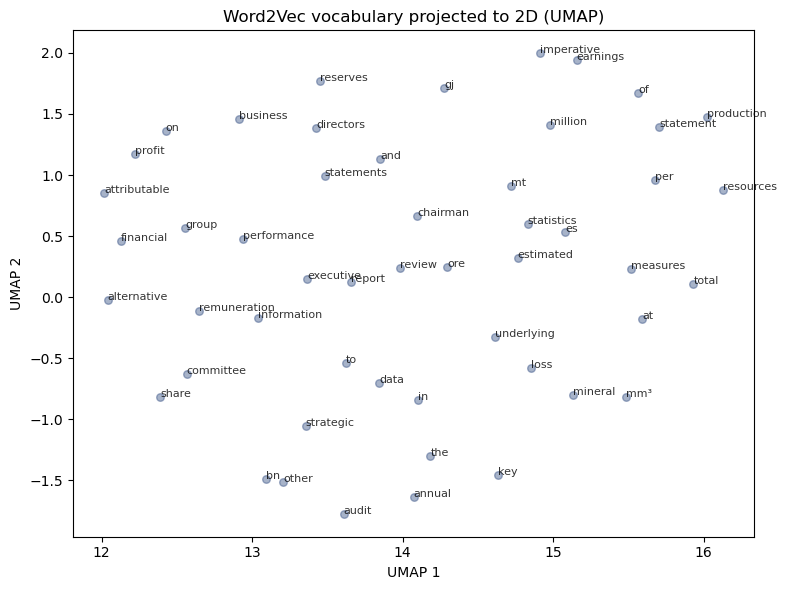

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=30, color="#24417A")
for i, word in enumerate(top_words):
    ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Word2Vec vocabulary projected to 2D (UMAP)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [44]:
w2v_embeddings = embed_chunks_w2v(emissions_df.to_dict(orient="records"), w2v_model)
w2v_embeddings.shape

Chunks with all-zero embeddings: 47/136


(136, 100)

In [ ]:
## Relevant information is that GHG EMISSIONS were 17.8 MtCO2e in 2016, 18.3Mt in 2015

In [46]:
QUERY_TEXT = 'What were GHG Emissions in 2015 and 2016 in MtCO2e?'

w2v_embeddings = rank_by_model(emissions_df.to_dict(orient="records"), QUERY_TEXT, w2v_model, "word2vec")
w2v_embeddings

Chunks with all-zero embeddings: 47/136


,rank,chunk_id,similarity,text_preview
0,1,669b1611eb909bc3acaa085aa9c7bf0e,0.697199,71 The Board in 2016...
1,2,e5d2f59fab3ff73fd24eff43d4c88729,0.535741,180 Exchange rates and commodity prices...
2,3,f2bdc5b52b64882cd2a1c65d5e0cf0be,0.535741,"54 Nickel, Niobium and Phosphates..."
3,4,e6a172a33a843d8f1f38f4dac463070a,0.380725,64 Corporate and other...
4,5,ac9543a46c089077094c673298a13345,0.354516,57 Iron Ore and Manganese...


In [49]:
# Check how many reference_ids are in top-5 for each
ref_set = {'cfd9d053225664f62c81b723c0ffaa22', '0df75e8a06175d03cae86f2fae58df61'}
hits = ref_set & set(w2v_embeddings["chunk_id"])

In [51]:
print(hits)

set()


## Analyse ANTAM's report structure

In [ ]:
from pypdf import PdfReader, PdfWriter
from tqdm import tqdm
import tempfile

reader = PdfReader(str(PDF_PATH))
elements = []

for i, page in enumerate(tqdm(reader.pages, desc="Partitioning pages")):
    writer = PdfWriter()
    writer.add_page(page)
    
    with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
        writer.write(tmp)
        tmp_path = tmp.name
    
    page_elements = partition_pdf(
        filename=tmp_path,
        strategy="fast",
        starting_page_number=i + 1
    )
    elements.extend(page_elements)
    os.unlink(tmp_path)

In [11]:
raw_texts = [
    el.text.strip()
    for el in tqdm(elements)
    if getattr(el, "text", None) and el.text.strip()
]

print(f"Elements extracted: {len(elements)}")
print(f"Text elements kept: {len(raw_texts)}")

100%|██████████| 44809/44809 [00:00<00:00, 1020689.22it/s]

Elements extracted: 44809
Text elements kept: 43450


In [12]:
lengths = [len(t) for t in raw_texts]
print(f"Min: {min(lengths)}, Median: {int(np.median(lengths))}, Max: {max(lengths)}")

Min: 1, Median: 20, Max: 2107


In [15]:
antam = chunk_by_element_type(elements, char_limit=1000, source_label=PDF_PATH.name)
antam = pd.DataFrame(antam).assign(char_count=lambda df: df["text"].str.len())

antam.describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,3107.0,853.15449,199.336121,75.0,748.0,892.0,973.0,2192.0


In [16]:
el_types = pd.Series([type(el).__name__ for el in elements if (getattr(el, "text", None) or "").strip()])
el_types.value_counts()

Title            19077
Text             11998
NarrativeText     7677
ListItem          2967
Footer            1454
Header             272
EmailAddress         5
Name: count, dtype: int64

## Test OCR strategy for table extraction from ANTAM

In [25]:
from pypdf import PdfWriter, PdfReader

reader = PdfReader(str(PDF_PATH))
writer = PdfWriter()
writer.add_page(reader.pages[29]) 

with open("data/interim/antam_temp_page.pdf", "wb") as f:
    writer.write(f)


In [7]:
ocr_source_elements = partition_pdf(
    filename="data/interim/antam_temp_page.pdf",
    strategy="ocr_only",
)

ocr_chunks = chunk_by_element_type(
    ocr_source_elements,
    char_limit=1000,
    source_label=PDF_PATH.name,
)

ocr_df = pd.DataFrame(ocr_chunks)

# Ensure text exists in DataFrame
if "text" not in ocr_df.columns:
    raise ValueError("ocr_df has no text column; inspect `ocr_chunks` right before DataFrame creation.")

ocr_df["char_count"] = ocr_df["text"].fillna("").str.len()
save_chunks_as_markdown(ocr_df, "data/interim/antam_ocr_only_chunks.md", "ocr_only")

print("done:", len(ocr_df), "chunks; assembly file data/interim/antam_ocr_only_chunks.md")

done: 5 chunks; assembly file data/interim/antam_ocr_only_chunks.md


In [ ]:
from pathlib import Path
import pdfplumber
import pandas as pd

TABLE_SETTINGS = {
    "vertical_strategy": "text",
    "horizontal_strategy": "text",
}

def cluster_into_rows(words: list[dict], tolerance: int = 3) -> dict[float, list[tuple]]:
    """Group pdfplumber word dicts into rows by snapping y0 to a grid.
    
    Args:
        words: List of word dicts from pdfplumber's extract_words().
        tolerance: Pixel tolerance for grouping words into the same row.
    
    Returns:
        Dict mapping snapped y-coordinate to list of (x0, text) tuples.
    """
    rows: dict[float, list[tuple]] = {}
    for word in words:
        y_key = round(word["top"] / tolerance) * tolerance
        if y_key not in rows:
            rows[y_key] = []
        rows[y_key].append((word["x0"], word["text"]))
    return rows


def rows_to_lines(rows: dict, label_boundary: float = 270.0) -> list[str]:
    """Join label words as prose, separate value columns with |."""
    result = []
    for y_key in sorted(rows.keys()):
        row_words = sorted(rows[y_key], key=lambda w: w[0])
        labels = [w[1] for w in row_words if w[0] < label_boundary]
        values = [w[1] for w in row_words if w[0] >= label_boundary]
        parts = []
        if labels:
            parts.append(" ".join(labels))
        if values:
            parts.append(" | ".join(values))
        result.append(" | ".join(parts))
    return result

out_md_path = Path("data/interim/antam_pdfplumber_tables.md")
lines = ["# pdfplumber table inspection", ""]

with pdfplumber.open("data/interim/antam_temp_page.pdf") as pdf:
    page = pdf.pages[0]

    # --- existing pdfplumber table extraction ---
    tables = page.extract_tables(table_settings=TABLE_SETTINGS)

    if not tables:
        lines.append("No tables detected")
    else:
        lines.append(f"Found {len(tables)} tables")
        lines.append("")
        for i, table in enumerate(tables):
            lines.append(f"## Table {i}")
            if not table:
                lines.append("_empty table_")
                lines.append("")
                continue
            header = table[0]
            body = table[1:]
            df = pd.DataFrame(body, columns=header)
            lines.append(df.to_markdown(index=False))
            lines.append("")

    # --- spatial clustering approach ---
    lines.append("## Spatial clustering (pymupdf-style on pdfplumber words)")
    lines.append("")
    words = page.extract_words()
    rows = cluster_into_rows(words, tolerance=3)
    clustered_lines = rows_to_lines(rows)
    for line in clustered_lines:
        lines.append(f"    {line}")  # indent for readability
    lines.append("")

    # --- word positions ---
    lines.append("## OCR word positions")
    text_elements = [{
        "text": word["text"],
        "element_type": "Word",
        "x0": word["x0"],
        "y0": word["top"],
        "x1": word["x1"],
        "y1": word["bottom"],
    } for word in words]
    text_df = pd.DataFrame(text_elements)
    lines.append(text_df.head(100).to_markdown(index=False))
    lines.append("")

out_md_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {out_md_path} (tables + clustering + OCR text position sample)")

Wrote data\interim\antam_pdfplumber_tables.md (tables + clustering + OCR text position sample)


## Manual Table Identification

In [1]:
from chunking import (
    score_page_table_likelihood,
    get_font_size_stats,
    is_table_page
)

ImportError: cannot import name 'score_page_table_likelihood' from 'chunking' (c:\Users\elimo\problem-set-2-elimossmarks11\chunking.py)